# The Dorion & François option_metrics module

In [1]:
%matplotlib inline
import internal_script # Allow absolute imports in internal scripts

# standard modules
import datetime as dt
import numpy as np
import pandas as pd
import os
import warnings

from concurrent.futures import ProcessPoolExecutor

# from the dorion_françois package
from dorion_francois.plot_utils import plt
import dorion_francois.black_merton_scholes as bms
from dorion_francois.toolkit import (
    assert_unique, nancorr, printdf, subcalendar, tic, toc)

# under development: this is bad practice ;)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import dorion_francois.option_metrics as om    

The following cell creates the secid108105_19960101_20221231/full.pkl file, but it is very heavy. First, om.wrds_connect allows you to connect to WRDS and fetch data directly from OptionMetrics. With double authentication, it sometimes stalls if done here first. But connecting with double authentication in a browser before calling om.wrds_connect usually circumvents this.

The start_date/end_date management in option_metrics is suboptimal, but that's what it is for now: set them before doing anything else. Here, we fetch the whole 96-22 universe of options on the SPX; takes forever.

The following cell loads the secid108105_19960101_20221231/full.pkl file, but it is burdensome to manipulate here. If we know we want to consider only (e.g.) the 2020 data, we can cache it once as follows.

Or we could be interested in focusing on options (e.g.) with roughly 30 DTM.

As of April 2023, in U.S. options markets, the traditional "standard" options 
that expire on the third Friday of each month are AM-settled. These options 
are settled based on the opening prices of their underlying securities on the 
morning of the expiration day. We'll focus on those below.

In [2]:
#del options
dirname = 'secid108105_19960101_20221231'
options = om.load_pickle(os.path.join(dirname,'full.pkl'))
options = options[options.am_settlement==1].copy()

We might want to parallelize some operations on these options. However, since we typically want to avoid splitting the panel of options observed on a single day, an naive split will not cut it. The proper way to deal with this would be to pass *approximately* equally-sized db_slices to each worker, and let them loop on the dates in the slice.

In [3]:
opt_sliced = om.Surface.slice(options)
opt = opt_sliced[0]
opt

,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,strike_price,best_bid,best_offer,...,is_call,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
0,108105.0,1996-01-04,09CA2.C9,0,1996-01-20,None,C,400000.0,215.125,216.1250,...,True,16,0.043836,0.057209,617.70,617.034125,617.681693,NaN,NaN,NaN
1,108105.0,1996-01-04,0A93B.59,0,1996-01-20,None,P,400000.0,0.000,0.0625,...,False,16,0.043836,0.057209,617.70,617.034125,617.681693,0.699778,0.088184,0.746052
2,108105.0,1996-01-04,0AA2D.58,0,1996-01-20,None,C,500000.0,115.375,116.3750,...,True,16,0.043836,0.057209,617.70,617.034125,617.681693,NaN,NaN,NaN
3,108105.0,1996-01-04,09BBC.DE,0,1996-01-20,None,C,525000.0,90.500,91.5000,...,True,16,0.043836,0.057209,617.70,617.034125,617.681693,NaN,NaN,NaN
4,108105.0,1996-01-04,09B4B.56,0,1996-01-20,1996-01-04,P,525000.0,0.000,0.1250,...,False,16,0.043836,0.057209,617.70,617.034125,617.681693,0.304742,0.033067,0.330725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893438,108105.0,2003-07-14,SXG.RW,0,2005-06-18,None,P,1300000.0,307.200,310.2000,...,False,705,1.931507,0.015129,1003.86,968.174441,997.471167,0.162951,0.157967,0.167737
893439,108105.0,2003-07-14,SXG.FA,0,2005-06-18,2003-07-10,C,1400000.0,6.100,7.5000,...,True,705,1.931507,0.015129,1003.86,968.174441,997.471167,0.158781,0.155077,0.162292
893440,108105.0,2003-07-14,SXG.RA,0,2005-06-18,2003-06-27,P,1400000.0,395.900,398.9000,...,False,705,1.931507,0.015129,1003.86,968.174441,997.471167,0.157027,0.148547,0.164526
893441,108105.0,2003-07-14,SYZ.FT,0,2005-06-18,2003-07-08,C,1500000.0,2.800,3.3000,...,True,705,1.931507,0.015129,1003.86,968.174441,997.471167,0.156706,0.154441,0.158861


As we can see below, a day in 1996 and one in 2022 won't exactly have the same number of observations.

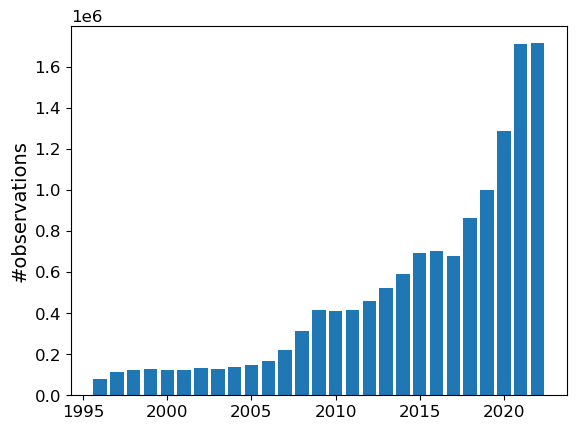

In [4]:
options['year'] = [date.year for date in options.date]
annual = options.groupby("year")
n_obs = annual[['symbol']].count()
plt.bar(n_obs.index, n_obs['symbol'])
plt.ylabel('#observations');

In the spirit of the discussion above, `om.Surface.map(opt_sliced, 'regress_dfw96')` iterates on the sliced data and runs the `om.Surface.regress_dfw96` on each surface (panel of observations on a given day) in the `options` db previously sliced.

In [5]:
if False:
    results = om.Surface.map(opt_sliced, 'regress_dfw96')
    om.dump_pickle(results, os.path.join(dirname,'regress_dfw96.pkl'))
else:
    results = om.load_pickle(
        os.path.join(dirname,'regress_dfw96.pkl') )
results

,est,lb,ub,date
RHS,,,,
const,0.148553,0.144783,0.152323,1996-01-04
MNY,-0.539819,-0.616290,-0.463349,1996-01-04
MNY**2,0.154108,-0.026512,0.334728,1996-01-04
YTM,-0.062941,-0.087236,-0.038646,1996-01-04
YTM**2,0.039890,0.027220,0.052560,1996-01-04
...,...,...,...,...
MNY**2,0.054316,0.050758,0.057875,2022-12-30
YTM,-0.027891,-0.033406,-0.022376,2022-12-30
YTM**2,0.006145,0.004888,0.007401,2022-12-30


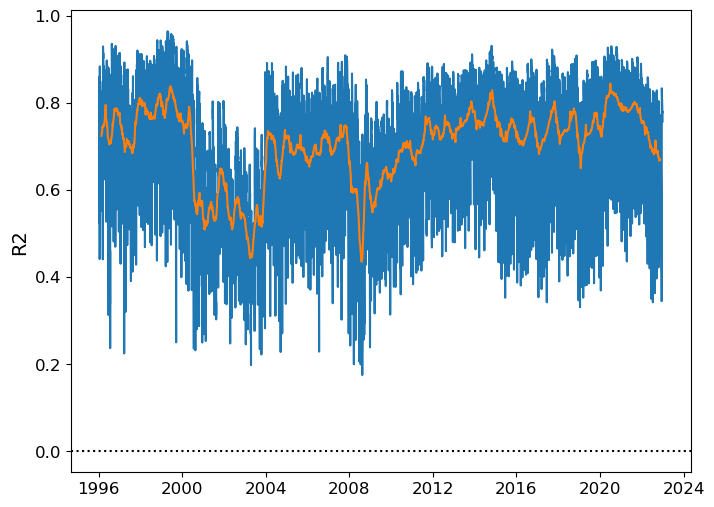

In [6]:
from dorion_francois.plot_utils import (mpl, plt, mtick, mdates, gridspec,
                                        set_plt_defaults, set_payoff_axes, set_time_axis, styles, with_style)

def plot_confidence_interval(ax, results, coeff_name, window=63):
    coeff = results.loc[coeff_name]
    coeff = coeff.set_index('date')
    
    est_w = coeff['est'].rolling(window, center=True)
    coeff['ma%d'%window] = est_w.mean()

    ax.plot(coeff.est, color='C0')
    ax.plot(coeff.lb, color='C0', linestyle='--')
    ax.plot(coeff.ub, color='C0', linestyle='--')
    ax.plot(coeff['ma%d'%window], color='C1')
    ax.axhline(0, color='k', linestyle=':')
    ax.set_ylabel(coeff_name)
    return coeff

fig, ax = plt.subplots(1, 1, figsize=(8,6))
R2 = plot_confidence_interval(ax, results, 'R2')

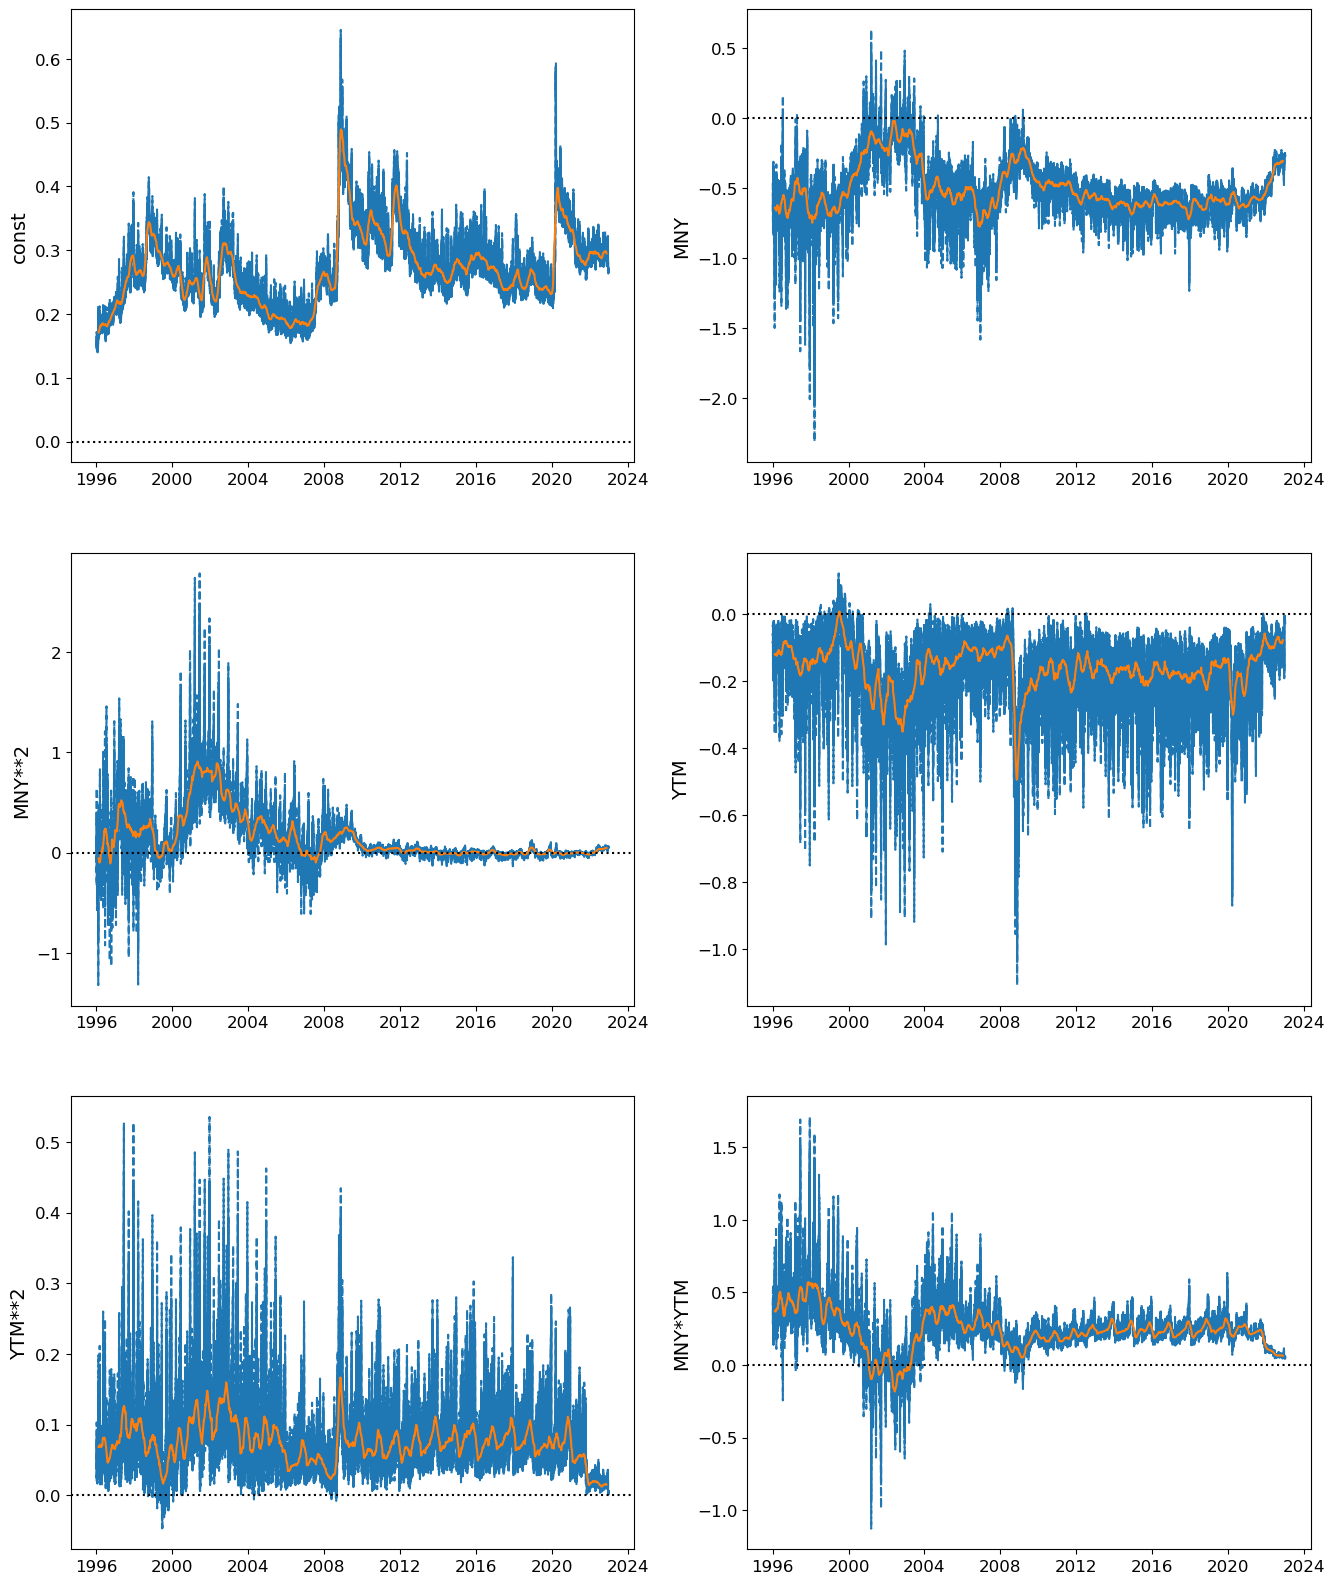

In [7]:
ix = ['const', 'MNY', 'MNY**2', 'YTM', 'YTM**2', 'MNY*YTM']
loadings = []
fig, axes = plt.subplots(3, 2, figsize=(16,20))
for no,ax in enumerate(axes.reshape(-1)):
    loadings.append(plot_confidence_interval(ax, results, ix[no]))
#ax = axes[-1,-1]
#R2 = plot_confidence_interval(ax, results, 'R2')
#ax = axes[-1,-2]
#ax.axis('off');

In [8]:
def get_ma(ar):
    return ar.loc[:,[col.startswith('ma') for col in ar.columns]]

loadings = loadings+[R2]
movag = [get_ma(beta) for beta in loadings]
labels = ['const', 'mny', 'mny2', 'ytm', 'ytm2', 'mny_ytm', 'R2']
M = pd.DataFrame([np.nanmean(beta) for beta in loadings],index=labels,columns=['mean'])
M.columns = pd.MultiIndex.from_tuples([('',col) for col in M.columns])
C = pd.DataFrame(nancorr(movag), index=labels, columns=labels)
C.columns = pd.MultiIndex.from_tuples([('correlations:',col) for col in C.columns])
pd.concat((M,C),axis=1)

correlations:                                          \
             mean         const       mny      mny2       ytm      ytm2   
const    0.270086      1.000000  0.166644 -0.131961 -0.461586  0.129350   
mny     -0.504259      0.166644  1.000000  0.789311 -0.470172  0.296782   
mny2     0.142531     -0.131961  0.789311  1.000000 -0.412931  0.533706   
ytm     -0.162537     -0.461586 -0.470172 -0.412931  1.000000 -0.814266   
ytm2     0.074318      0.129350  0.296782  0.533706 -0.814266  1.000000   
mny_ytm  0.236005     -0.292932 -0.775321 -0.421064  0.476087 -0.090256   
R2       0.702937      0.056978 -0.867196 -0.676368  0.393310 -0.245376   

                             
          mny_ytm        R2  
const   -0.292932  0.056978  
mny     -0.775321 -0.867196  
mny2    -0.421064 -0.676368  
ytm      0.476087  0.393310  
ytm2    -0.090256 -0.245376  
mny_ytm  1.000000  0.652192  
R2       0.652192  1.000000

In [9]:
M = 12
n_paths = [[0, 1.25 * 2**8 * M, 0]]
for no in range(1,12*10):
    dead,single,double = n_paths[no-1]
    n_paths.append( [(single+double)/4, (single+double)/2, 2*(single+double)/4] )
n_paths = np.array(n_paths)
total_number_paths = n_paths[0,1] + np.sum(n_paths[:,0],axis=0)
print(n_paths[:3,:])
total_number_paths

[[   0. 3840.    0.]
 [ 960. 1920. 1920.]
 [ 960. 1920. 1920.]]


118080.0

For reference, the code below is rather useful in a notebook:

```
if True:
    import pdb, sys
    # When debugging, this reloads the option_metrics package, without having to 
    # reload the data above.
    import importlib
    importlib.reload(om)
    import dorion_francois.option_metrics as om     
```